# PSTAT 100 Final Project

**Authors: Kody Lai, Jeffrey Tat, Anthony Saenez, Stanley Lin, Noah Ruderman**

In [2]:
# Libraries
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

# Figure formatting
sns.set_style("whitegrid")
sns.set_palette("Set2")

## Data Collection

In [3]:
# JSON taken from saving https://api.skinport.com/v1/sales/history?currency=USD

df = pd.read_json('data/skinport_items.json')
df.to_csv('data/skinport_items.csv', index=False)
print(df.head())

df = df.drop(columns=['item_page', 'market_page', 'last_24_hours', 'last_7_days', 'last_90_days']) # remove unnecessary data: both pages (just urls) and unused time scales
print(df.shape)
df.head()

                             market_hash_name version currency  \
0  Sticker Slab | BIG (Gold) | Stockholm 2021     NaN      USD   
1  Sticker Slab | Kvik (Foil) | Katowice 2019     NaN      USD   
2         Sticker Slab | B1ad3 | Cologne 2015     NaN      USD   
3                   Sticker Slab | Pocket BBQ     NaN      USD   
4          Sticker Slab | oSee | Antwerp 2022     NaN      USD   

                                           item_page  \
0  https://skinport.com/item/sticker-slab-big-gol...   
1  https://skinport.com/item/sticker-slab-kvik-fo...   
2  https://skinport.com/item/sticker-slab-b1ad3-c...   
3  https://skinport.com/item/sticker-slab-pocket-bbq   
4  https://skinport.com/item/sticker-slab-osee-an...   

                                         market_page  \
0  https://skinport.com/market?item=BIG%20(Gold)%...   
1  https://skinport.com/market?item=Kvik%20(Foil)...   
2  https://skinport.com/market?item=B1ad3%20%7C%2...   
3  https://skinport.com/market?item=Pocket

,market_hash_name,version,currency,last_30_days
0,Sticker Slab | BIG (Gold) | Stockholm 2021,NaN,USD,"{'min': None, 'max': None, 'avg': None, 'media..."
1,Sticker Slab | Kvik (Foil) | Katowice 2019,NaN,USD,"{'min': None, 'max': None, 'avg': None, 'media..."
2,Sticker Slab | B1ad3 | Cologne 2015,NaN,USD,"{'min': None, 'max': None, 'avg': None, 'media..."
3,Sticker Slab | Pocket BBQ,NaN,USD,"{'min': None, 'max': None, 'avg': None, 'media..."
4,Sticker Slab | oSee | Antwerp 2022,NaN,USD,"{'min': None, 'max': None, 'avg': None, 'media..."


In [4]:
last_30_days = pd.json_normalize(df['last_30_days']) # expand the dictionary of last_30_days into a temporary data frame

df = df.join(last_30_days)
df=df.drop(columns='last_30_days')

df.head()

,market_hash_name,version,currency,min,max,avg,median,volume
0,Sticker Slab | BIG (Gold) | Stockholm 2021,NaN,USD,NaN,NaN,NaN,NaN,0
1,Sticker Slab | Kvik (Foil) | Katowice 2019,NaN,USD,NaN,NaN,NaN,NaN,0
2,Sticker Slab | B1ad3 | Cologne 2015,NaN,USD,NaN,NaN,NaN,NaN,0
3,Sticker Slab | Pocket BBQ,NaN,USD,NaN,NaN,NaN,NaN,0
4,Sticker Slab | oSee | Antwerp 2022,NaN,USD,NaN,NaN,NaN,NaN,0


                  Missing Values  Percent Missing
market_hash_name               0         0.000000
version                    32889        97.146655
currency                       0         0.000000
min                        16205        47.865899
max                        16205        47.865899
avg                        16205        47.865899
median                     16205        47.865899
volume                         0         0.000000


<Axes: >

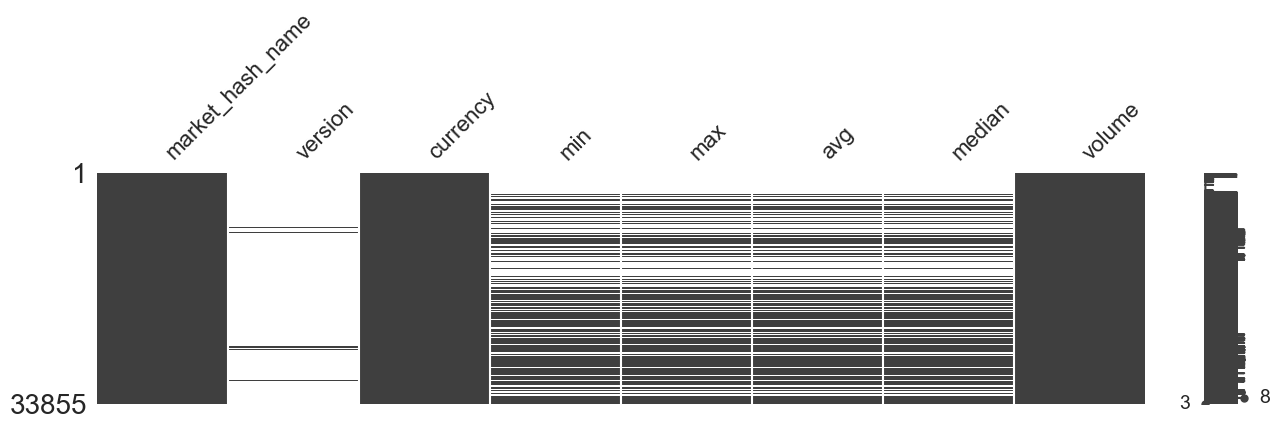

In [5]:
missing_table = pd.DataFrame({
        'Missing Values': df.isna().sum(), 
        'Percent Missing': df.isna().mean() * 100
    })

print(missing_table)

msno.matrix(df, figsize=(15, 3)) 



In [6]:
# All the missing data seems to be all from the same entries, so we will remove rows where every statistic is missing
df = df.dropna(subset=["min", "max", "avg", "median"], how="all") # version is not dropped as None *is* a valid version rather than representing null

new_missing_table = pd.DataFrame({
        'Missing Values': df.isna().sum(), 
        'Percent Missing': df.isna().mean() * 100
    })

print(new_missing_table)
print(df.shape) # removed exactly 16205 entires, as expected
df.head()

                  Missing Values  Percent Missing
market_hash_name               0         0.000000
version                    17251        97.739377
currency                       0         0.000000
min                            0         0.000000
max                            0         0.000000
avg                            0         0.000000
median                         0         0.000000
volume                         0         0.000000
(17650, 8)


,market_hash_name,version,currency,min,max,avg,median,volume
210,Souvenir AK-47 | Steel Delta (Field-Tested),NaN,USD,4.06,8.61,5.35,4.87,7
332,Souvenir XM1014 | Hieroglyph (Factory New),NaN,USD,0.56,1.20,0.99,1.04,6
343,Souvenir MAG-7 | Copper Coated (Field-Tested),NaN,USD,0.35,1.16,0.59,0.44,4
580,Souvenir P90 | ScaraB Rush (Well-Worn),NaN,USD,4.92,4.92,4.92,4.92,1
2795,AK-47 | Black Laminate (Well-Worn),NaN,USD,58.03,58.03,58.03,58.03,1


In [ ]:
# break market_has_name into souvenir, weapon, skin, and condition

df["souvenir"] = df["market_hash_name"].str.contains("Souvenir")
df["stat_trak"] = df["market_hash_name"].str.contains("StatTrak")

temp_df = df[df["market_hash_name"].str.contains("AK-47|M4A4|AWP")]

temp_df.head()
df = temp_df
df.head()

,market_hash_name,version,currency,min,max,avg,median,volume,souvenir,stat_trak
210,Souvenir AK-47 | Steel Delta (Field-Tested),NaN,USD,4.06,8.61,5.35,4.87,7,True,False
2795,AK-47 | Black Laminate (Well-Worn),NaN,USD,58.03,58.03,58.03,58.03,1,False,False
2813,AK-47 | Aquamarine Revenge (Battle-Scarred),NaN,USD,27.33,35.98,32.02,31.67,7,False,False
2814,AK-47 | Fire Serpent (Factory New),NaN,USD,2485.40,2625.52,2555.46,2555.46,2,False,False
2908,AK-47 | Predator (Battle-Scarred),NaN,USD,9.23,9.68,9.46,9.45,2,False,False


In [39]:
# seperate market hash name into different variables
df[['weapon', 'skin', 'condition']] = df['market_hash_name'].str.extract(r'(.+?)\s*\|\s*(.+?)\s*\((.+?)\)', expand=True)

# embellishments (souvenir, stattrak) are unecessary to remove because we will filter weapon types through .contains() anyways

df=df.drop(columns='market_hash_name')
df.head()


,version,currency,min,max,avg,median,volume,souvenir,stat_trak,weapon,skin,condition
210,NaN,USD,4.06,8.61,5.35,4.87,7,True,False,Souvenir AK-47,Steel Delta,Field-Tested
2795,NaN,USD,58.03,58.03,58.03,58.03,1,False,False,AK-47,Black Laminate,Well-Worn
2813,NaN,USD,27.33,35.98,32.02,31.67,7,False,False,AK-47,Aquamarine Revenge,Battle-Scarred
2814,NaN,USD,2485.40,2625.52,2555.46,2555.46,2,False,False,AK-47,Fire Serpent,Factory New
2908,NaN,USD,9.23,9.68,9.46,9.45,2,False,False,AK-47,Predator,Battle-Scarred


In [40]:
# map values to condition for linear regression purposes
condition_codes = {
    "Factory New": 4, 
    "Minimal Wear": 3, 
    "Field-Tested": 2,
    "Well-Worn": 1, 
    "Battle-Scarred": 0,
}

# recode age categories
df_enc = df.replace({'condition': condition_codes})

df = df_enc

df.head()

,version,currency,min,max,avg,median,volume,souvenir,stat_trak,weapon,skin,condition
210,NaN,USD,4.06,8.61,5.35,4.87,7,True,False,Souvenir AK-47,Steel Delta,2
2795,NaN,USD,58.03,58.03,58.03,58.03,1,False,False,AK-47,Black Laminate,1
2813,NaN,USD,27.33,35.98,32.02,31.67,7,False,False,AK-47,Aquamarine Revenge,0
2814,NaN,USD,2485.40,2625.52,2555.46,2555.46,2,False,False,AK-47,Fire Serpent,4
2908,NaN,USD,9.23,9.68,9.46,9.45,2,False,False,AK-47,Predator,0


In [41]:
# write to csv for others to use

df.to_csv('data/skinport_items_cleaned.csv', index=False)